# Credit Risk — Linear Regression (OLS) Pipeline

Reuses the group data pipeline (load → target definition → leakage removal → derogatory-history exclusion → stratified split), then fits an **ordinary least squares linear regression** on the binary `bad` target and evaluates it as a risk-scoring model with AUC, KS, Gini, and related metrics.

**Note on OLS for a 0/1 target:** the model's output is a continuous *risk score*, not a calibrated probability (it can fall outside [0, 1]). Ranking metrics like AUC and KS are still fully valid on this score; if calibrated probabilities are needed later, swap `LinearRegression` for `LogisticRegression`.

## 1. Load the data

10,000-row simple random sample (10%) of the full 100k dataset, `random_state=42`. Update `PATH` to wherever the workbook lives in your environment.

In [1]:
import pandas as pd
import numpy as np

PATH = 'credit_risk_dataset_v2_sample10k.xlsx'  # e.g. '/content/sample_data/credit_risk_dataset_v2_sample10k.xlsx'

df = pd.read_excel(PATH, sheet_name='Customer Data')
print(df.shape)

(10000, 538)


## 2. Define the target `bad` and remove leakage columns

Same rule as the group notebook: `bad = 1` if any of the three risk attributes cross their threshold. Those three columns are then dropped from the features so the model can't learn the labeling rule directly.

In [2]:
df['bad'] = (
    (df['risk_attribute_383060'] >= 8) |
    (df['risk_attribute_274389'] > 0) |
    (df['risk_attribute_272634'] > 0)
).astype(int)
print(df['bad'].value_counts())
print("Bad rate:", df['bad'].mean())

leakage_cols = ['risk_attribute_383060', 'risk_attribute_274389', 'risk_attribute_272634']

bad
0    9841
1     159
Name: count, dtype: int64
Bad rate: 0.0159


## 3. Exclude derogatory-history features

Fairness/policy step from the group pipeline: uses the workbook's Data Dictionary to flag and drop any column describing past derogatory credit history (bankruptcies, charge-offs, collections, delinquencies, liens, etc.).

In [3]:
dd = pd.read_excel(PATH, sheet_name='Data Dictionary')

derog_categories = {
    'Worst Status Codes', 'Collections and Derogatory Metrics', 'Public Records and Bankruptcy',
    'Financial Stress and Hardship Indicators', 'Months Since Delinquency',
    'Delinquency Counts – 30 Days', 'Delinquency Counts – 60 Days and Severe',
    'Delinquency Percentages', 'Additional Delinquency Severity and Recurrence'
}
keywords = ['charge-off','chargeoff','bankrupt','delinquen','derogatory','collection',
            'default','write-off','writeoff','garnishment','hardship','nsf','judgment',
            'lien','forbearance','deferment','settled']

def is_derogatory(row):
    cat = row['Category']
    definition = str(row['Definition']).lower()
    return cat in derog_categories or any(k in definition for k in keywords)

exclude_cols = dd[dd.apply(is_derogatory, axis=1)]['Column Name'].tolist()
print(f"Excluding {len(exclude_cols)} derogatory-history columns")

X_clean = df.drop(columns=['customer_id', 'bad'] + leakage_cols + exclude_cols, errors='ignore')
y = df['bad']
print("X_clean shape:", X_clean.shape)
print("Missing values:", X_clean.isnull().sum().sum())

Excluding 293 derogatory-history columns
X_clean shape: (10000, 244)
Missing values: 0


## 4. Train/test split

80/20 stratified split, `random_state=42` — identical to the group notebook so results are comparable across models.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(8000, 244) (2000, 244)
0.015875 0.016


## 5. Fit the OLS linear regression

Features are standardized first (regression coefficients are scale-sensitive), then a plain `LinearRegression` is fit on the 0/1 target. The prediction is a continuous risk score.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('scaler', StandardScaler()),
    ('ols', LinearRegression())
])
model.fit(X_train, y_train)

score_test = model.predict(X_test)   # continuous risk score
print("Score range on test set:", score_test.min().round(3), "to", score_test.max().round(3))

Score range on test set: -0.075 to 0.464


## 6. Evaluation metrics

- **ROC-AUC** — probability a random bad customer scores higher than a random good one.
- **Gini** = 2·AUC − 1 — the standard credit-risk restatement of AUC.
- **KS statistic** — maximum separation between the cumulative score distributions of goods vs. bads (both the ROC-based and two-sample versions are computed as a cross-check).
- **PR-AUC** — more informative than ROC-AUC under heavy class imbalance (~1.6% bad rate).
- **R² / RMSE** — regression-style fit diagnostics, reported since this is an OLS model.

In [6]:
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, r2_score, mean_squared_error,
                             average_precision_score)
from scipy.stats import ks_2samp

auc  = roc_auc_score(y_test, score_test)
gini = 2*auc - 1
fpr, tpr, thresholds = roc_curve(y_test, score_test)
ks_idx = np.argmax(tpr - fpr)
ks, ks_cutoff = (tpr - fpr)[ks_idx], thresholds[ks_idx]
ks_scipy = ks_2samp(score_test[y_test == 1], score_test[y_test == 0]).statistic
pr_auc = average_precision_score(y_test, score_test)
r2   = r2_score(y_test, score_test)
rmse = mean_squared_error(y_test, score_test) ** 0.5

print(f"ROC-AUC : {auc:.4f}")
print(f"Gini    : {gini:.4f}")
print(f"KS      : {ks:.4f}  (at score cutoff {ks_cutoff:.4f}; two-sample KS = {ks_scipy:.4f})")
print(f"PR-AUC  : {pr_auc:.4f}")
print(f"R^2     : {r2:.4f}")
print(f"RMSE    : {rmse:.4f}")

ROC-AUC : 0.9781
Gini    : 0.9563
KS      : 0.9062  (at score cutoff 0.0662; two-sample KS = 0.9062)
PR-AUC  : 0.4205
R^2     : 0.2255
RMSE    : 0.1104


## 7. Classification report at the KS-optimal cutoff

OLS has no natural 0.5 threshold, so predictions are cut at the score where KS is maximized (the point of best good/bad separation). Adjust the cutoff to match business priorities.

In [7]:
y_pred = (score_test >= ks_cutoff).astype(int)

print(f"At KS-optimal cutoff = {ks_cutoff:.4f}:")
print(classification_report(y_test, y_pred, target_names=['Approve (0)', 'Deny (1)']))
print(confusion_matrix(y_test, y_pred))

At KS-optimal cutoff = 0.0662:
              precision    recall  f1-score   support

 Approve (0)       1.00      0.94      0.97      1968
    Deny (1)       0.20      0.97      0.33        32

    accuracy                           0.94      2000
   macro avg       0.60      0.95      0.65      2000
weighted avg       0.99      0.94      0.96      2000

[[1845  123]
 [   1   31]]


## 8. ROC curve and KS plot

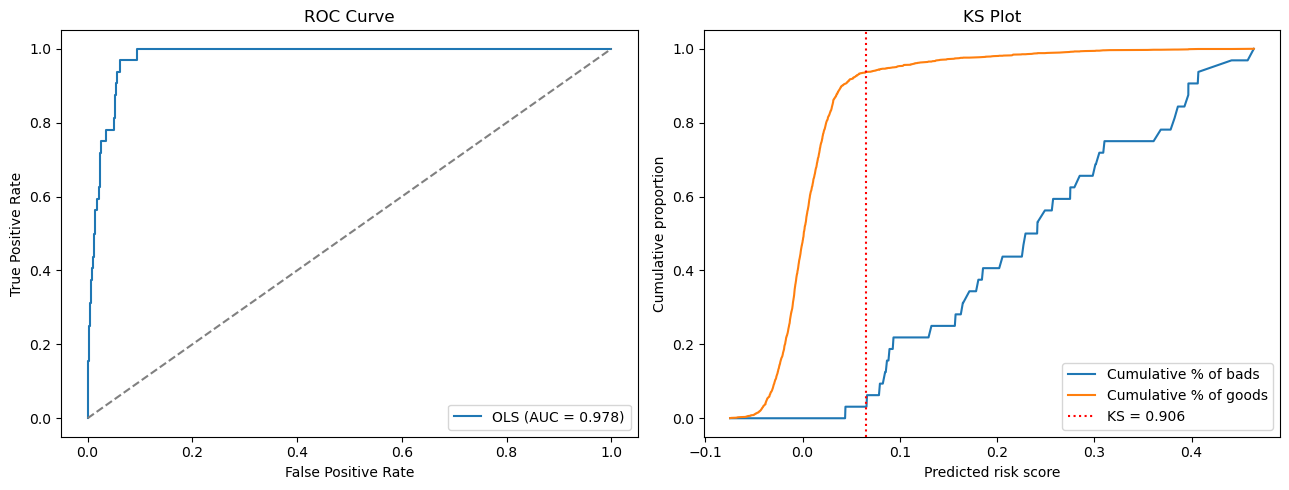

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, label=f'OLS (AUC = {auc:.3f})')
axes[0].plot([0,1], [0,1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

# KS plot: cumulative distributions of scores for goods vs bads
order = np.argsort(score_test)
s_sorted, y_sorted = score_test[order], y_test.values[order]
cum_bad  = np.cumsum(y_sorted) / y_sorted.sum()
cum_good = np.cumsum(1 - y_sorted) / (1 - y_sorted).sum()
axes[1].plot(s_sorted, cum_bad, label='Cumulative % of bads')
axes[1].plot(s_sorted, cum_good, label='Cumulative % of goods')
ks_x = s_sorted[np.argmax(cum_good - cum_bad)]
axes[1].axvline(ks_x, color='red', linestyle=':', label=f'KS = {ks:.3f}')
axes[1].set_xlabel('Predicted risk score'); axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('KS Plot'); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Decile lift table

Test customers sorted into 10 equal score bands (decile 10 = highest risk score). A good risk model concentrates the bads in the top deciles.

In [9]:
dec = pd.DataFrame({'score': score_test, 'bad': y_test.values})
dec['decile'] = pd.qcut(dec['score'].rank(method='first'), 10, labels=False) + 1
lift = (dec.groupby('decile')
           .agg(n=('bad','size'), bads=('bad','sum'), bad_rate=('bad','mean'))
           .sort_index(ascending=False))
lift['cum_bads_pct'] = lift['bads'].cumsum() / lift['bads'].sum()
print(lift)

          n  bads  bad_rate  cum_bads_pct
decile                                   
10      200    31     0.155       0.96875
9       200     1     0.005       1.00000
8       200     0     0.000       1.00000
7       200     0     0.000       1.00000
6       200     0     0.000       1.00000
5       200     0     0.000       1.00000
4       200     0     0.000       1.00000
3       200     0     0.000       1.00000
2       200     0     0.000       1.00000
1       200     0     0.000       1.00000


## 10. Top model coefficients

Since features were standardized, coefficient magnitude is directly comparable — the largest absolute coefficients are the features the linear model leans on most.

In [10]:
coefs = pd.Series(model.named_steps['ols'].coef_, index=X_clean.columns)
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20))

risk_attribute_320281   -0.023331
risk_attribute_246991    0.018755
risk_attribute_196781    0.017380
risk_attribute_855731    0.015949
risk_attribute_808011    0.009770
risk_attribute_741390    0.009721
risk_attribute_947272   -0.009182
risk_attribute_542374    0.008836
risk_attribute_543692    0.008337
risk_attribute_220116    0.007197
risk_attribute_599948    0.006827
risk_attribute_216970   -0.005772
risk_attribute_712554   -0.005485
risk_attribute_407757   -0.005304
risk_attribute_300896    0.005293
risk_attribute_170674   -0.004743
risk_attribute_292401    0.004569
risk_attribute_982554   -0.004402
risk_attribute_456699   -0.004134
risk_attribute_159642    0.003947
dtype: float64
